# Deep Learning for State Poverty Rate Prediction

**Objective:** Apply deep learning methods to predict US state poverty rates using socio-economic predictors.

**Methodology:** Following the approach from the Somalia poverty study (Nature Scientific Reports 2024), we implement:
- Neural Networks with keras
- Random Forest for comparison
- Feature importance analysis
- Model performance evaluation (RMSE, R², MAE)

**Data:** State-level cross-sectional data (n=50) for 2023

## 1. Setup and Data Loading

In [2]:
# Install required packages
install.packages(c("keras3", "tidyverse", "randomForest", "caret", "MLmetrics", "gridExtra"))

library(keras3)
library(tidyverse)
library(caret)
library(MLmetrics)

trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/keras3_1.5.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/tidyverse_2.0.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/randomForest_4.7-1.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/caret_7.0-1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/MLmetrics_1.1.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/gridExtra_2.3.1.tgz'



The downloaded binary packages are in
	/var/folders/zm/_0b9h87s3hz5gs_zytrkxl5w0000gn/T//Rtmpz0A3mV/downloaded_packages
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: lattice

Attaching package: ‘caret’

The following object is masked from ‘package:purrr’:

    lift


Attaching package: ‘MLmetrics’

The following objects are masked from ‘package:caret’:

    MAE, RMSE

The following object is masked from ‘package:base’:

    Recall



In [3]:
data <- read_csv("/Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/data/processed/dataset.csv")
# Display structure
summary(data)

Rows: 50 Columns: 28
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): State
dbl (26): Unemployment Rate, average Rent (/month), Apartment Size (Sq Ft), ...
num  (1): Population density (people per square mile)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


       State    Population density (people per square mile) Unemployment Rate
 Length   :50   Min.   :   1.00                             Min.   :2.070    
 N.unique :50   1st Qu.:  45.25                             1st Qu.:3.045    
 N.blank  : 0   Median : 105.50                             Median :3.475    
 Min.nchar: 4   Mean   : 200.08                             Mean   :3.534    
 Max.nchar:14   3rd Qu.: 219.50                             3rd Qu.:4.030    
                Max.   :1218.00                             Max.   :5.610    
 average Rent (/month) Apartment Size (Sq Ft)
 Min.   : 686.0        Min.   :471.0         
 1st Qu.: 746.8        1st Qu.:669.2         
 Median : 806.5        Median :698.5         
 Mean   : 905.6        Mean   :690.2         
 3rd Qu.:1009.8        3rd Qu.:720.8         
 Max.   :1659.0        Max.   :766.0         
 MedianHouseholdIncome_2019_2021Dollars MedianHourlyWage_2019
 Min.   :48500                          Min.   :15.00        
 1st Qu.

## 2. Data Preparation

In [5]:
# Remove State column (keep only numeric predictors and outcome)
# Outcome variable is 'poverty'
data_clean <- data %>%
  select(-State) %>%
  na.omit()

# Check final dimensions
cat("Final dataset:", nrow(data_clean), "observations,", ncol(data_clean), "variables\n")
cat("Outcome variable: poverty\n")
cat("Number of predictors:", ncol(data_clean) - 1, "\n")

Final dataset: 50 observations, 27 variables
Outcome variable: poverty
Number of predictors: 26 


In [6]:
# Train-test split (80-20)
set.seed(2026)
train_idx <- sample(1:nrow(data_clean), size = 0.8 * nrow(data_clean))

train_data <- data_clean[train_idx, ]
test_data <- data_clean[-train_idx, ]

cat("Training set:", nrow(train_data), "observations\n")
cat("Test set:", nrow(test_data), "observations\n")

Training set: 40 observations
Test set: 10 observations


In [7]:
# Separate X and y
# Outcome variable is 'poverty'
X_train <- train_data %>% select(-Poverty_Percentage) %>% as.matrix()
y_train <- train_data$Poverty_Percentage

X_test <- test_data %>% select(-Poverty_Percentage) %>% as.matrix()
y_test <- test_data$Poverty_Percentage

In [8]:

# Normalize features (standardization)
# Explicitly calling caret to ensure the function is found
preproc <- caret::preProcess(X_train, method = c("center", "scale"))
X_train_scaled <- predict(preproc, X_train)
X_test_scaled <- predict(preproc, X_test)

## 3. Neural Network Model


In [9]:
# Define neural network architecture
# Simple feedforward network with 2 hidden layers
nn_model <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = "relu", input_shape = ncol(X_train_scaled)) %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 32, activation = "relu") %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 1)  # Output layer for regression

summary(nn_model)

/Users/yeonjune.kim.27/Library/Caches/org.R-project.R/R/reticulate/uv/cache/archive-v0/jDWZfeSds0cbYMS8/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 64)               │         1,728 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 1)                │            33 │
└───────

In [10]:
# Compile model
nn_model %>% compile(
  loss = "mse",
  optimizer = optimizer_adam(learning_rate = 0.001),
  metrics = c("mae")
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 79.5955 - mae: 8.5359 - val_loss: 64.3762 - val_mae: 7.8460
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 71.0148 - mae: 8.0675 - val_loss: 59.8749 - val_mae: 7.5497
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70.6742 - mae: 7.9260 - val_loss: 55.6409 - val_mae: 7.2569
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 62.8247 - mae: 7.4980 - val_loss: 51.7089 - val_mae: 6.9711
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 58.8597 - mae: 7.1874 - val_loss: 47.8115 - val_mae: 6.6758
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 52.0501 - mae: 6.6991 - val_loss: 44.0561 - val_mae: 6.3796
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 51.8688 - mae: 6.7729 - val_loss: 40.4088 - val_mae: 6.0784
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 44.1895 - mae: 6.1805 - val_loss: 36.9008 - val_mae: 5.7727
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

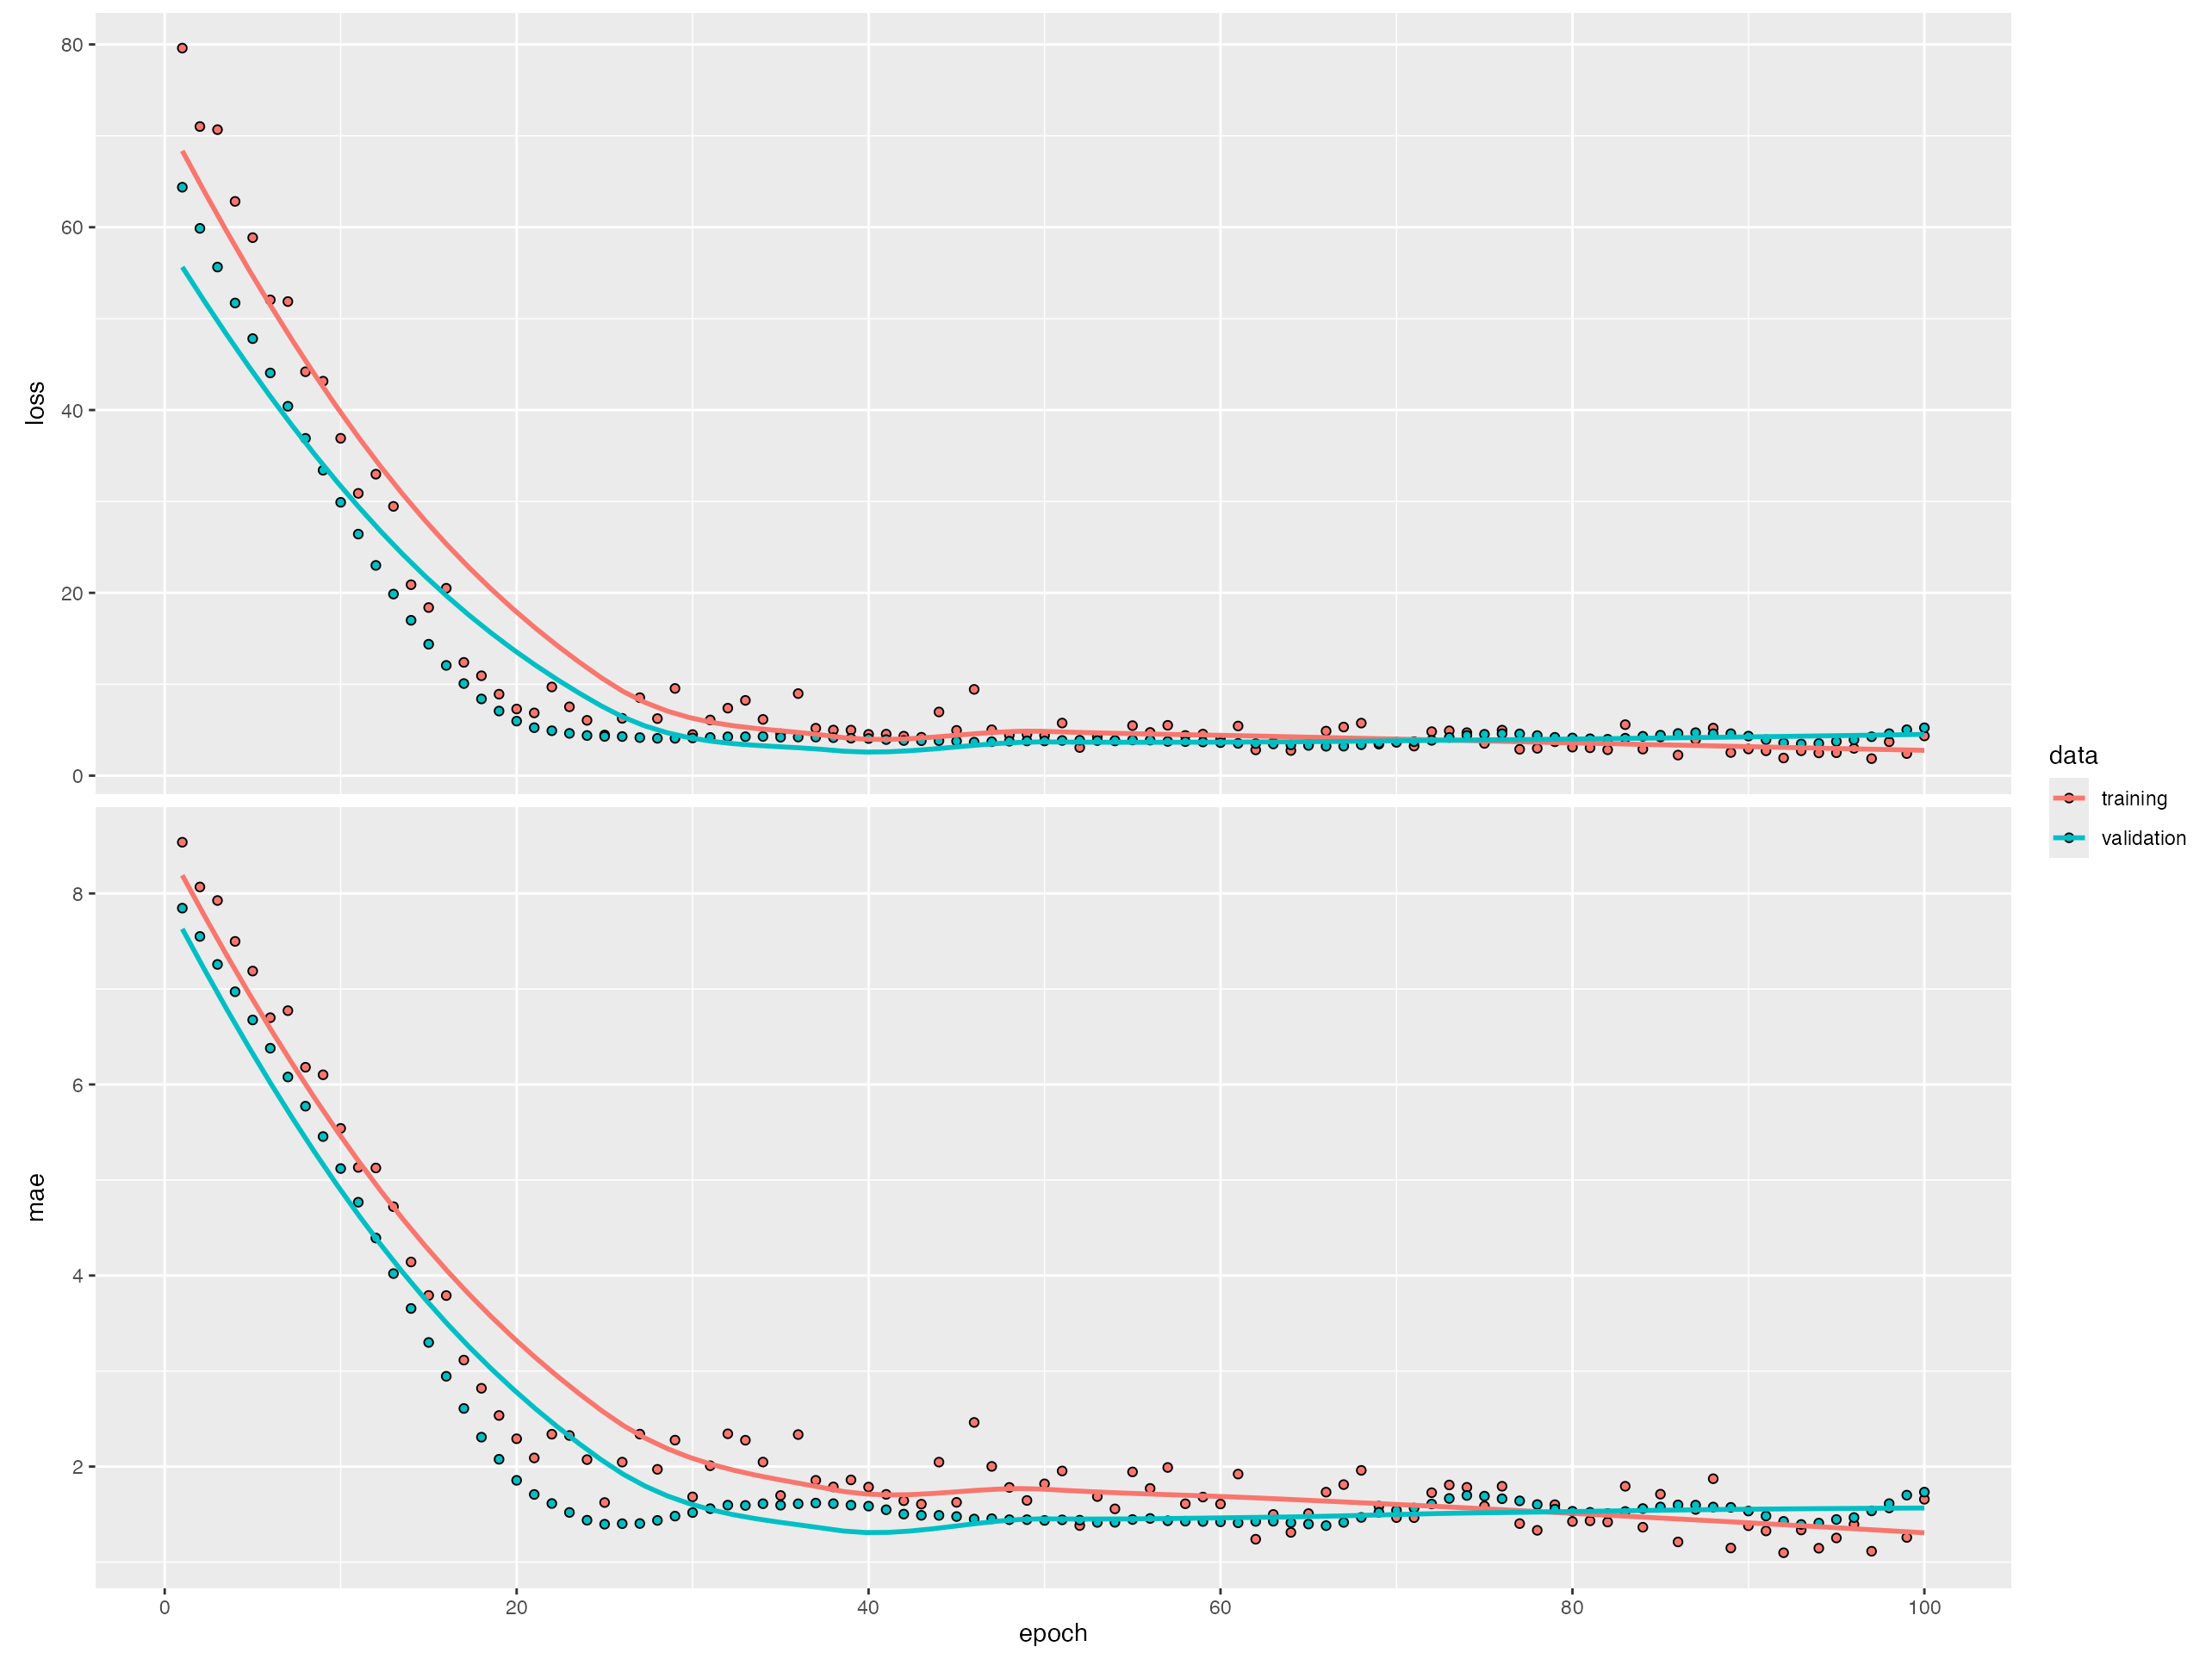

In [11]:
# Train model
history <- nn_model %>% fit(
  X_train_scaled, y_train,
  epochs = 100,
  batch_size = 8,
  validation_split = 0.2,
  verbose = 1
)

plot(history)

In [12]:
summary(nn_model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 64)               │         1,728 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 1)                │            33 │
└───────


##4. L2 Regularization ##


In [28]:
 l2_lambda <- 0.02  # Regularization strength (can tune this)

  nn_model_l2 <- keras_model_sequential() %>%
    layer_dense(units = 64,
                activation = "relu",
                input_shape = ncol(X_train_scaled),
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 32,
                activation = "relu",
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 1,
                kernel_regularizer = regularizer_l2(l2_lambda))

  summary(nn_model_l2)

Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                    ┃ Output Shape                                    ┃                     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                                                 │ (None, 64)                                      │                       1,728 │
├─────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────┼─────────────────────────────┤
│ dropout_6 (Dropout)                                             │ (None, 64)                                      │                           0 │
├─────────────────────────────────────────────────────────────────┼───────────────────────

In [29]:
  # Compile model with L2 regularization
  nn_model_l2 %>% compile(
    loss = "mse",
    optimizer = optimizer_adam(learning_rate = 0.001),
    metrics = c("mae")
  )

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 85.6802 - mae: 8.8200 - val_loss: 73.1854 - val_mae: 8.3252
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 81.9232 - mae: 8.6100 - val_loss: 68.2279 - val_mae: 8.0173
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 75.1170 - mae: 8.2013 - val_loss: 63.6313 - val_mae: 7.7208
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 69.1163 - mae: 7.8329 - val_loss: 59.1246 - val_mae: 7.4200
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 65.3918 - mae: 7.5791 - val_loss: 54.9092 - val_mae: 7.1263
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 57.7404 - mae: 7.1039 - val_loss: 50.8058 - val_mae: 6.8298
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 56.8585 - mae: 7.0036 - val_loss: 46.8605 - val_mae: 6.5315
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 51.8477 - mae: 6.7001 - val_loss: 43.0160 - val_mae: 6.2254
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

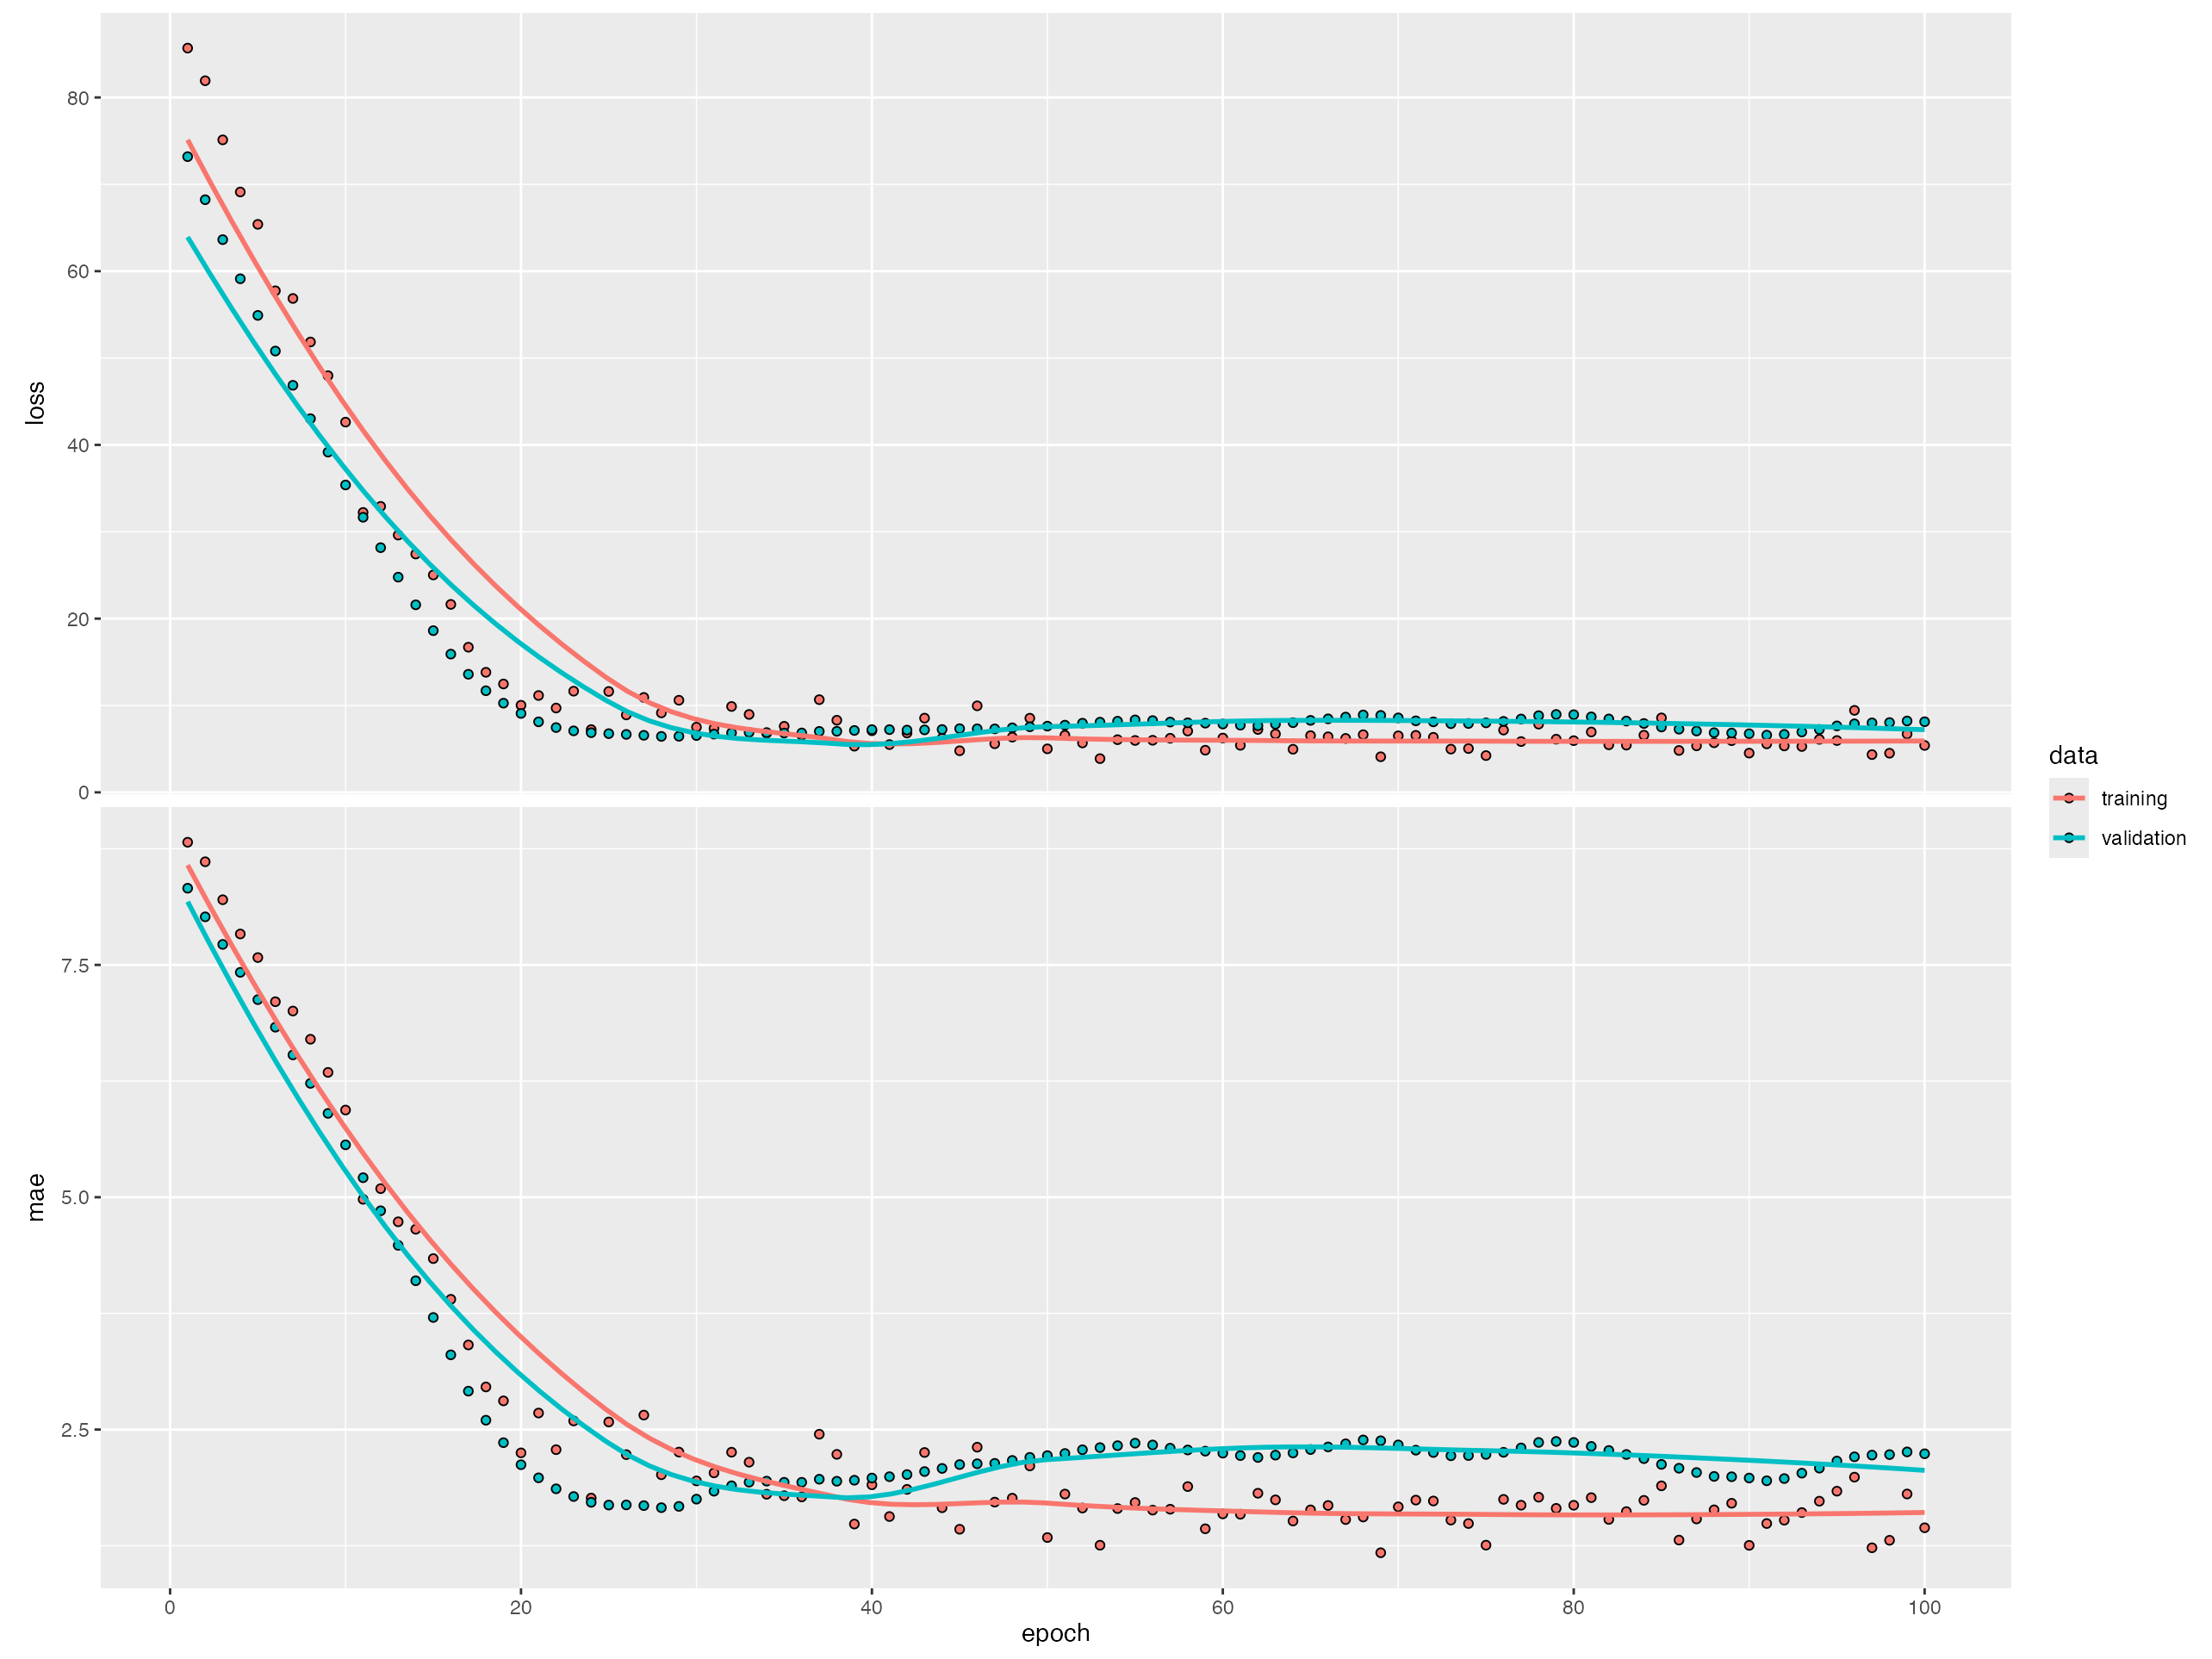

In [30]:
  # Train model with L2 regularization
  history_l2 <- nn_model_l2 %>% fit(
    X_train_scaled, y_train,
    epochs = 100,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
  )

  plot(history_l2)

In [31]:
# Evaluate original model
  pred_original <- nn_model %>% predict(X_test_scaled)
  rmse_original <- sqrt(mean((y_test - pred_original)^2))
  mae_original <- mean(abs(y_test - pred_original))

  # Evaluate L2 regularized model
  pred_l2 <- nn_model_l2 %>% predict(X_test_scaled)
  rmse_l2 <- sqrt(mean((y_test - pred_l2)^2))
  mae_l2 <- mean(abs(y_test - pred_l2))

  # Print comparison
  cat("Original Model:\n")
  cat("  RMSE:", rmse_original, "\n")
  cat("  MAE:", mae_original, "\n\n")

  cat("L2 Regularized Model:\n")
  cat("  RMSE:", rmse_l2, "\n")
  cat("  MAE:", mae_l2, "\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Original Model:
  RMSE: 4.661262 
  MAE: 3.393378 

L2 Regularized Model:
  RMSE: 3.757176 
  MAE: 2.78933 


In [ ]:
models_dir <- "/Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/models"                                                                                                         
  if (!dir.exists(models_dir)) {
    dir.create(models_dir, recursive = TRUE)                                                                                                                                                 
  }               

  model_path <- file.path(models_dir, "nn_model_l2_poverty_prediction.keras")
  save_model(nn_model_l2, model_path, overwrite=TRUE)

  cat("Model saved to:", model_path, "\n")

  preproc_path <- file.path(models_dir, "preprocessing_scaler.rds")
  saveRDS(preproc, preproc_path)

  cat("Preprocessing scaler saved to:", preproc_path, "\n")

: [1m[33mError[39m:[22m
[33m![39m File '/Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/models/nn_model_l2_poverty_prediction.keras' already exists (pass overwrite = TRUE to force save).